In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la

In [144]:
class StateVector:
    def __init__(self, state):
        self.state = state
    
    def normalize(self):
        self.state = self.state/la.norm(self.state)

    def dim(self):
        return len(self.state)

    def apply(self, U):
        return U.mat@self.state

    
    def inner(self, other):
        if type(other)== np.ndarray :
            return np.vdot(self.state, other)
        else:
            return np.vdot(self.state, other.state)
    def tensor(self, other):
        if type(other)== np.ndarray:
            product = np.kron(self.state, other)
        else: 
            product = np.kron(self.state, other.state)
        return StateVector(product)

In [ ]:

class Operator:
    def __init__(self, array):
        self.mat = array

    def conj(self): 
        self.mat = np.conj(self.mat).T

    def spectrum(self):
        E, V = la.eigh(self.mat)
        return E, V
    
    def expectation(self,state):
        O_psi = state.apply(self)
        return state.inner(O_psi)

class sz(Operator):
    def __init__(self):
        super().__init__(np.array([[1, 0], [0, -1]]))


In [149]:
test_state = StateVector(np.array([0,1]))

sz().expectation(test_state)

-1

In [78]:
psi0 = np.array([1,1])
state_0 = StateVector(psi0)

In [79]:
psi_test = np.array([np.sqrt(1/2),np.sqrt(1/2)])

state_test = StateVector(psi_test)


In [80]:
state_0.tensor(state_test).state

array([0.70710678, 0.70710678, 0.70710678, 0.70710678])

In [81]:
op = np.array([[2,3],[1,1]])
op = Operator(op)
state_0.apply(op)

array([5, 2])

In [82]:
np.kron(psi0,psi_test)

array([0.70710678, 0.70710678, 0.70710678, 0.70710678])

In [83]:
state_0.dim()

2

# Quantum Geometry 

Certain hamiltonians such as $H = J \sigma^x + g \sigma^z$ exhibit topological effects as you evolve them. You could perhaps plot a trajectory of a point on the bloch sphere to show that the chern number ( a measure of topological order also sometimes called winding number) changes. 


# Rabi Oscillations

https://en.wikipedia.org/wiki/Rabi_cycle

Rabi oscillations allow people to control where their qubit is pointing. You can very easily plot the behavior of the rabi oscillations under the two "knobs" they can turn, frequency $\omega$ and  detuning $\Delta$.

But Also, you can look into some real-quantum effects. Such as dephasing or detuning. I dont know specifics, but you can look into these effects and how they might disrupt a rabi cycle. You can for instance plot the elements of the densit ymatrix $\rho$ and show that it becomes a statistical mixture at long times.

In [ ]:
# setting parameters and defining the Hamiltonian

w0 = 1                              # the frequency that controls stationary part
w1 = 0.5                                # frequency that controls the oscillating part
w = 2                                       # frequency inside the oscillating terms
t = np.arange(1,50,0.01)                             # time steps
H = np.zeros((len(t), 2, 2), dtype=complex)             # Hamiltonian initialization

H[:, 0, 0] = w0
H[:, 1, 1] = -w0
H[:, 0, 1] = w1 * np.exp(-1j * w * t)
H[:, 1, 0] = w1 * np.exp(1j * w * t)

In [ ]:
# setting up a test state

test_state = np.array([1,0])

In [ ]:
# calculating time evolved state

from scipy.linalg import expm

psi = test_state.astype(complex)

dt = t[1] - t[0]
psi_t = []

for i in range(len(t)):
    psi_t.append(psi)
    U = expm(-1j * H[i] * dt)
    psi = U @ psi

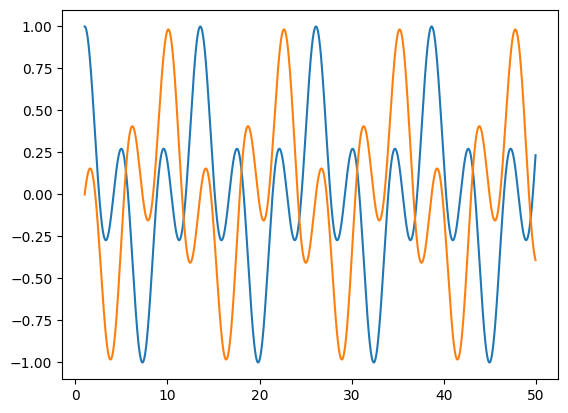

In [240]:
plt.plot(t, (np.real(psi_t)), '-')

In [241]:
np.real(psi_t)

array([[ 1.        ,  0.        ],
       [ 0.9999375 ,  0.00454639],
       [ 0.99975002,  0.0090506 ],
       ...,
       [ 0.216709  , -0.38638466],
       [ 0.22521671, -0.38841753],
       [ 0.2337538 , -0.39034087]])

In [242]:
prob_t = []
psi = psi0.copy()
psi1 = np.array([0,1])
for i in range(len(t)):
    amp = np.vdot(psi1, psi)        # <1|psi(t)>
    prob_t.append(np.abs(amp)**2)

    #evolve the state forward
    U = expm(-1j * H[i] * dt)
    psi = U @ psi

In [243]:
np.real(prob_t)

array([0.00000000e+00, 2.49989584e-05, 9.99933336e-05, ...,
       3.64468259e-01, 3.59662388e-01, 3.54870551e-01])

<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
/var/folders/4t/t515wkn52_9_fj_wtsmnsf2w0000gn/T/ipykernel_54305/338775740.py:4: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$<1|\psi(t)>$')


Text(0, 0.5, '$<1|\\psi(t)>$')

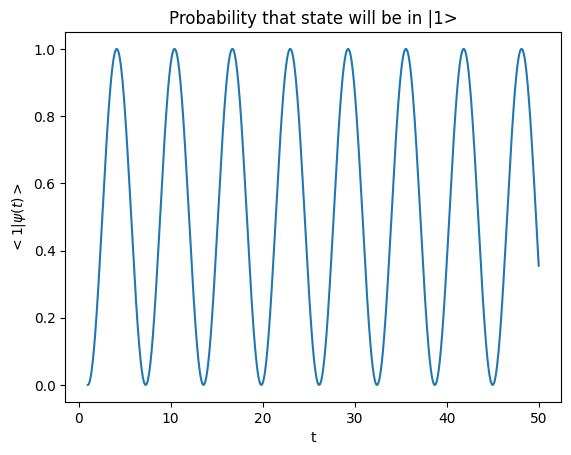

In [249]:
plt.plot(t, prob_t)
plt.title('Probability that state will be in |1>')
plt.xlabel('t')
plt.ylabel('$<1|\psi(t)>$')